In [7]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

RAW_PATH = Path("../data/raw/market_data.csv")
PROCESSED_DIR = Path("../data/processed")
OUTPUT_PATH = PROCESSED_DIR / "features.csv"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [8]:
raw = pd.read_csv(RAW_PATH, header=[0, 1], index_col=0)

raw.index = pd.to_datetime(raw.index, errors="coerce")
raw = raw[raw.index.notna()]
raw.index.name = "Date"

raw = raw.apply(pd.to_numeric, errors="coerce")

print(raw.shape)
raw.head()

(4133, 20)


Price             Close                                              High  \
Ticker            ^GSPC        ^IXIC        ^NSEI       ^VIX        ^GSPC   
Date                                                                        
2010-01-04  1132.989990  2308.419922  5232.200195  20.040001  1133.869995   
2010-01-05  1136.520020  2308.709961  5277.899902  19.350000  1136.630005   
2010-01-06  1137.140015  2301.090088  5281.799805  19.160000  1139.189941   
2010-01-07  1141.689941  2300.050049  5263.100098  19.059999  1142.459961   
2010-01-08  1144.979980  2317.169922  5244.750000  18.129999  1145.390015   

Price                                                    Low               \
Ticker            ^IXIC        ^NSEI       ^VIX        ^GSPC        ^IXIC   
Date                                                                        
2010-01-04  2311.149902  5238.450195  21.680000  1116.560059  2294.409912   
2010-01-05  2313.729980  5288.350098  20.129999  1129.660034  2295.620117   
2010-01-06  2314.070068  5310.850098  19.680000  1133.949951  2295.679932   
2010-01-07  2301.300049  5302.549805  19.709999  1131.319946  2285.219971   
2010-01-08  2317.600098  5276.750000  19.270000  1136.219971  2290.610107   

Price                                      Open                            \
Ticker            ^NSEI       ^VIX        ^GSPC        ^IXIC        ^NSEI   
Date                                                                        
2010-01-04  5167.100098  20.030001  1116.560059  2294.409912  5200.899902   
2010-01-05  5242.399902  19.340000  1132.660034  2307.270020  5277.149902   
2010-01-06  5260.049805  18.770000  1135.709961  2307.709961  5278.149902   
2010-01-07  5244.750000  18.700001  1136.270020  2298.090088  5281.799805   
2010-01-08  5234.700195  18.110001  1140.520020  2292.239990  5264.250000   

Price                        Volume                           
Ticker           ^VIX         ^GSPC         ^IXIC ^NSEI ^VIX  
Date                                                          
2010-01-04  21.680000  3.991400e+09  1.931380e+09   0.0  0.0  
2010-01-05  20.049999  2.491020e+09  2.367860e+09   0.0  0.0  
2010-01-06  19.590000  4.972660e+09  2.253340e+09   0.0  0.0  
2010-01-07  19.680000  5.270680e+09  2.270050e+09   0.0  0.0  
2010-01-08  19.270000  4.389590e+09  2.145390e+09   0.0  0.0

In [9]:
market = raw.copy()

market.columns = pd.MultiIndex.from_tuples(
    [(price, ticker) for price, ticker in market.columns],
    names=["Price", "ticker"]
)

market = (
    market
    .stack(level="ticker")
    .reset_index()
)

market.columns.name = None

print(market.columns.tolist())
print(market.shape)

market.head()

['Date', 'ticker', 'Close', 'High', 'Low', 'Open', 'Volume']
(16532, 7)


,Date,ticker,Close,High,Low,Open,Volume
0,2010-01-04,^GSPC,1132.989990,1133.869995,1116.560059,1116.560059,3.991400e+09
1,2010-01-04,^IXIC,2308.419922,2311.149902,2294.409912,2294.409912,1.931380e+09
2,2010-01-04,^NSEI,5232.200195,5238.450195,5167.100098,5200.899902,0.000000e+00
3,2010-01-04,^VIX,20.040001,21.680000,20.030001,21.680000,0.000000e+00
4,2010-01-05,^GSPC,1136.520020,1136.630005,1129.660034,1132.660034,2.491020e+09


In [10]:
def add_technical_features(group):
    group = group.sort_values("Date").copy()

    group["return_1d"] = group["Close"].pct_change()
    group["log_return_1d"] = np.log(group["Close"] / group["Close"].shift(1))

    group["volatility_7d"] = group["return_1d"].rolling(7).std()
    group["volatility_14d"] = group["return_1d"].rolling(14).std()
    group["volatility_30d"] = group["return_1d"].rolling(30).std()
    group["volatility_60d"] = group["return_1d"].rolling(60).std()

    group["ma_20"] = group["Close"].rolling(20).mean()
    group["ma_50"] = group["Close"].rolling(50).mean()
    group["ma_100"] = group["Close"].rolling(100).mean()
    group["ma_200"] = group["Close"].rolling(200).mean()

    group["ma_20_ratio"] = group["Close"] / group["ma_20"] - 1
    group["ma_50_ratio"] = group["Close"] / group["ma_50"] - 1
    group["ma_200_ratio"] = group["Close"] / group["ma_200"] - 1

    group["momentum_7d"] = group["Close"] / group["Close"].shift(7) - 1
    group["momentum_14d"] = group["Close"] / group["Close"].shift(14) - 1
    group["momentum_30d"] = group["Close"] / group["Close"].shift(30) - 1
    group["momentum_60d"] = group["Close"] / group["Close"].shift(60) - 1

    group["rolling_max"] = group["Close"].cummax()
    group["drawdown"] = group["Close"] / group["rolling_max"] - 1

    group["high_low_range"] = group["High"] / group["Low"] - 1
    group["volume_change"] = group["Volume"].pct_change()

    group["target_return_1d"] = group["return_1d"].shift(-1)
    group["target_direction_1d"] = (group["target_return_1d"] > 0).astype(int)

    return group

In [11]:
features = (
    market
    .groupby("ticker", group_keys=False)
    .apply(add_technical_features)
    .reset_index(drop=True)
)

print(features.columns.tolist())
features.head()

['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'return_1d', 'log_return_1d', 'volatility_7d', 'volatility_14d', 'volatility_30d', 'volatility_60d', 'ma_20', 'ma_50', 'ma_100', 'ma_200', 'ma_20_ratio', 'ma_50_ratio', 'ma_200_ratio', 'momentum_7d', 'momentum_14d', 'momentum_30d', 'momentum_60d', 'rolling_max', 'drawdown', 'high_low_range', 'volume_change', 'target_return_1d', 'target_direction_1d']


,Date,Close,High,Low,Open,Volume,return_1d,log_return_1d,volatility_7d,volatility_14d,...,momentum_7d,momentum_14d,momentum_30d,momentum_60d,rolling_max,drawdown,high_low_range,volume_change,target_return_1d,target_direction_1d
0,2010-01-04,1132.989990,1133.869995,1116.560059,1116.560059,3.991400e+09,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1132.989990,0.0,0.015503,NaN,0.003116,1
1,2010-01-04,2308.419922,2311.149902,2294.409912,2294.409912,1.931380e+09,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2308.419922,0.0,0.007296,NaN,0.000126,1
2,2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0.000000e+00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5232.200195,0.0,0.013809,NaN,0.008734,1
3,2010-01-04,20.040001,21.680000,20.030001,21.680000,0.000000e+00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,20.040001,0.0,0.082376,NaN,-0.034431,0
4,2010-01-05,1136.520020,1136.630005,1129.660034,1132.660034,2.491020e+09,0.003116,0.003111,NaN,NaN,...,NaN,NaN,NaN,NaN,1136.520020,0.0,0.006170,-0.375903,0.000546,1


In [13]:
if "ticker" not in features.columns:
    features = features.copy()
    features["ticker"] = market["ticker"].values

vix_data = features[features["ticker"].isin(["^VIX", "VIX"])][
    ["Date", "Close", "return_1d", "volatility_30d"]
].copy()

vix_data = vix_data.rename(columns={
    "Close": "vix_close",
    "return_1d": "vix_return_1d",
    "volatility_30d": "vix_volatility_30d"
})

features = features.merge(vix_data, on="Date", how="left")

features.head()

,Date,Close,High,Low,Open,Volume,return_1d,log_return_1d,volatility_7d,volatility_14d,...,rolling_max,drawdown,high_low_range,volume_change,target_return_1d,target_direction_1d,ticker,vix_close,vix_return_1d,vix_volatility_30d
0,2010-01-04,1132.989990,1133.869995,1116.560059,1116.560059,3.991400e+09,NaN,NaN,NaN,NaN,...,1132.989990,0.0,0.015503,NaN,0.003116,1,^GSPC,20.040001,NaN,NaN
1,2010-01-04,2308.419922,2311.149902,2294.409912,2294.409912,1.931380e+09,NaN,NaN,NaN,NaN,...,2308.419922,0.0,0.007296,NaN,0.000126,1,^IXIC,20.040001,NaN,NaN
2,2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0.000000e+00,NaN,NaN,NaN,NaN,...,5232.200195,0.0,0.013809,NaN,0.008734,1,^NSEI,20.040001,NaN,NaN
3,2010-01-04,20.040001,21.680000,20.030001,21.680000,0.000000e+00,NaN,NaN,NaN,NaN,...,20.040001,0.0,0.082376,NaN,-0.034431,0,^VIX,20.040001,NaN,NaN
4,2010-01-05,1136.520020,1136.630005,1129.660034,1132.660034,2.491020e+09,0.003116,0.003111,NaN,NaN,...,1136.520020,0.0,0.006170,-0.375903,0.000546,1,^GSPC,19.350000,-0.034431,NaN


In [14]:
model_features = [
    "return_1d",
    "log_return_1d",
    "volatility_7d",
    "volatility_14d",
    "volatility_30d",
    "volatility_60d",
    "ma_20_ratio",
    "ma_50_ratio",
    "ma_200_ratio",
    "momentum_7d",
    "momentum_14d",
    "momentum_30d",
    "momentum_60d",
    "drawdown",
    "high_low_range",
    "volume_change",
    "vix_close",
    "vix_return_1d",
    "vix_volatility_30d",
]

target_cols = [
    "target_return_1d",
    "target_direction_1d"
]

base_cols = [
    "Date",
    "ticker",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
]

final_cols = base_cols + model_features + target_cols

features_clean = features[final_cols].copy()

features_clean = features_clean.replace([np.inf, -np.inf], np.nan)

features_clean = features_clean.dropna(
    subset=[
        "return_1d",
        "volatility_30d",
        "momentum_30d",
        "drawdown",
        "target_return_1d"
    ]
)

features_clean = features_clean.sort_values(["ticker", "Date"]).reset_index(drop=True)

print(features_clean.shape)
features_clean.head()

(5098, 28)


,Date,ticker,Open,High,Low,Close,Volume,return_1d,log_return_1d,volatility_7d,...,momentum_30d,momentum_60d,drawdown,high_low_range,volume_change,vix_close,vix_return_1d,vix_volatility_30d,target_return_1d,target_direction_1d
0,2010-03-30,^GSPC,1173.750000,1177.829956,1168.920044,1173.270020,4.085000e+09,0.000043,0.000043,0.004552,...,0.071607,0.032336,-0.000767,0.007622,-0.066409,17.129999,-0.026151,0.033997,-0.003273,0
1,2010-03-31,^GSPC,1171.750000,1174.560059,1165.770020,1169.430054,4.484340e+09,-0.003273,-0.003278,0.004594,...,0.063592,0.028396,-0.004037,0.007540,0.097758,17.590000,0.026854,0.034446,0.007414,1
2,2010-04-01,^GSPC,1171.229980,1181.430054,1170.689941,1178.099976,4.006870e+09,0.007414,0.007386,0.004654,...,0.064468,0.031891,0.000000,0.009174,-0.106475,17.469999,-0.006822,0.033442,0.007928,1
3,2010-04-05,^GSPC,1178.709961,1187.729980,1178.709961,1187.439941,3.881620e+09,0.007928,0.007897,0.004543,...,0.070566,0.037084,0.000000,0.007652,-0.031259,17.020000,-0.025758,0.033352,0.001684,1
4,2010-04-06,^GSPC,1186.010010,1191.800049,1182.770020,1189.439941,4.086180e+09,0.001684,0.001683,0.004200,...,0.073492,0.037019,0.000000,0.007635,0.052700,16.230000,-0.046416,0.034203,-0.005877,0


In [15]:
features_clean = features_clean[features_clean["ticker"] != "^VIX"].copy()

print(features_clean["ticker"].value_counts())
features_clean.head()

ticker
^GSPC    1404
^IXIC    1404
^NSEI     886
Name: count, dtype: int64


,Date,ticker,Open,High,Low,Close,Volume,return_1d,log_return_1d,volatility_7d,...,momentum_30d,momentum_60d,drawdown,high_low_range,volume_change,vix_close,vix_return_1d,vix_volatility_30d,target_return_1d,target_direction_1d
0,2010-03-30,^GSPC,1173.750000,1177.829956,1168.920044,1173.270020,4.085000e+09,0.000043,0.000043,0.004552,...,0.071607,0.032336,-0.000767,0.007622,-0.066409,17.129999,-0.026151,0.033997,-0.003273,0
1,2010-03-31,^GSPC,1171.750000,1174.560059,1165.770020,1169.430054,4.484340e+09,-0.003273,-0.003278,0.004594,...,0.063592,0.028396,-0.004037,0.007540,0.097758,17.590000,0.026854,0.034446,0.007414,1
2,2010-04-01,^GSPC,1171.229980,1181.430054,1170.689941,1178.099976,4.006870e+09,0.007414,0.007386,0.004654,...,0.064468,0.031891,0.000000,0.009174,-0.106475,17.469999,-0.006822,0.033442,0.007928,1
3,2010-04-05,^GSPC,1178.709961,1187.729980,1178.709961,1187.439941,3.881620e+09,0.007928,0.007897,0.004543,...,0.070566,0.037084,0.000000,0.007652,-0.031259,17.020000,-0.025758,0.033352,0.001684,1
4,2010-04-06,^GSPC,1186.010010,1191.800049,1182.770020,1189.439941,4.086180e+09,0.001684,0.001683,0.004200,...,0.073492,0.037019,0.000000,0.007635,0.052700,16.230000,-0.046416,0.034203,-0.005877,0


In [16]:
features_clean.to_csv(OUTPUT_PATH, index=False)

print("Saved processed features to:", OUTPUT_PATH)
print("Rows:", len(features_clean))
print("Columns:", len(features_clean.columns))

Saved processed features to: ..\data\processed\features.csv
Rows: 3694
Columns: 28


In [17]:
features_clean.groupby("ticker")[[
    "return_1d",
    "volatility_30d",
    "momentum_30d",
    "drawdown",
    "vix_close",
    "target_return_1d"
]].describe()

return_1d                                                              \
           count      mean       std       min       25%       50%       75%   
ticker                                                                         
^GSPC     1404.0  0.000605  0.010923 -0.059750 -0.003848  0.000800  0.005721   
^IXIC     1404.0  0.000735  0.013162 -0.059681 -0.004779  0.000879  0.007500   
^NSEI      886.0  0.000446  0.008685 -0.059151 -0.004468  0.000467  0.005799   

                 volatility_30d            ...  vix_close             \
             max          count      mean  ...        75%        max   
ticker                                     ...                         
^GSPC   0.095154         1404.0  0.010204  ...  21.510000  57.060001   
^IXIC   0.121632         1404.0  0.012281  ...  21.510000  57.060001   
^NSEI   0.028131          886.0  0.008474  ...  22.137499  40.740002   

       target_return_1d                                                    \
                  count      mean       std       min       25%       50%   
ticker                                                                      
^GSPC            1404.0  0.000598  0.010932 -0.059750 -0.003799  0.000840   
^IXIC            1404.0  0.000758  0.013184 -0.059681 -0.004744  0.000926   
^NSEI             886.0  0.000529  0.008681 -0.059151 -0.004411  0.000535   

                            
             75%       max  
ticker                      
^GSPC   0.005699  0.095154  
^IXIC   0.007440  0.121632  
^NSEI   0.006033  0.028131  

[3 rows x 48 columns]

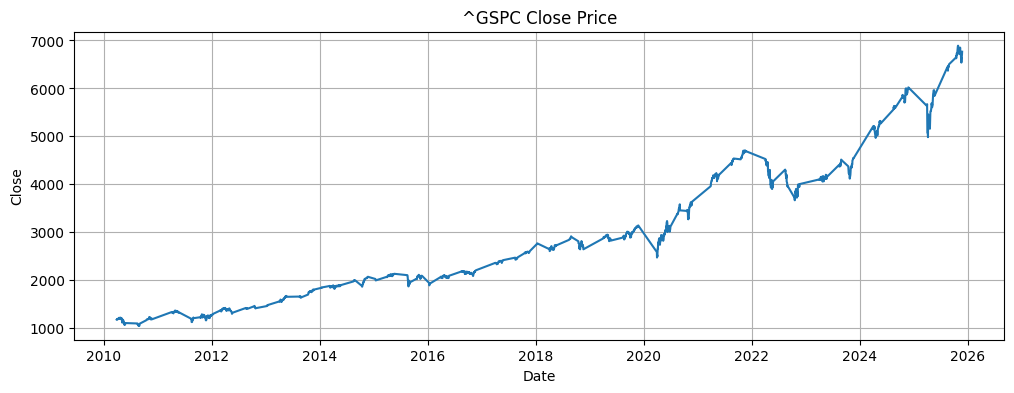

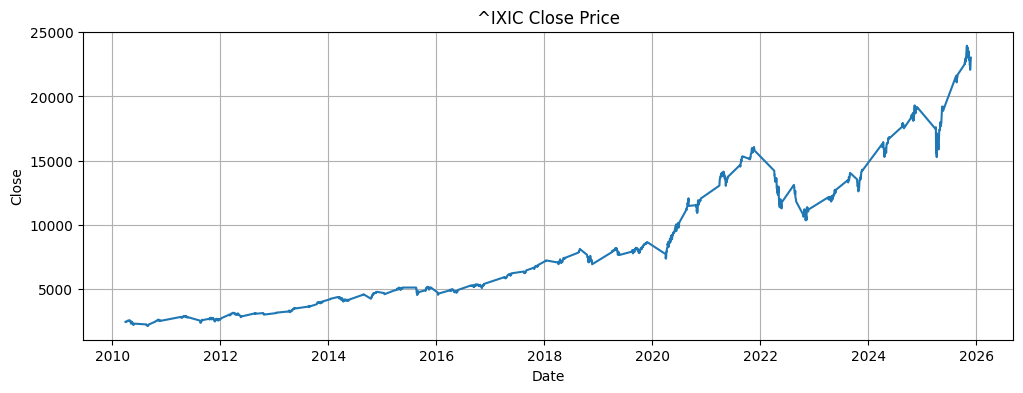

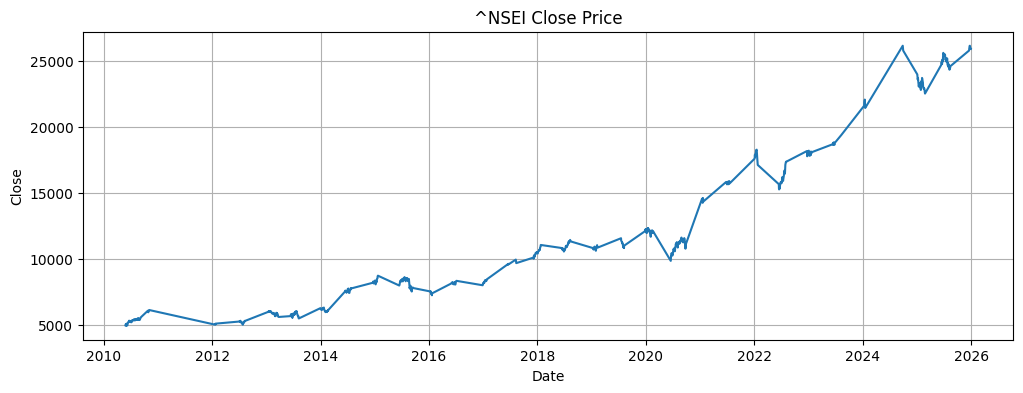

In [18]:
for ticker in features_clean["ticker"].unique():
    temp = features_clean[features_clean["ticker"] == ticker]

    plt.figure(figsize=(12, 4))
    plt.plot(temp["Date"], temp["Close"])
    plt.title(f"{ticker} Close Price")
    plt.xlabel("Date")
    plt.ylabel("Close")
    plt.grid(True)
    plt.show()

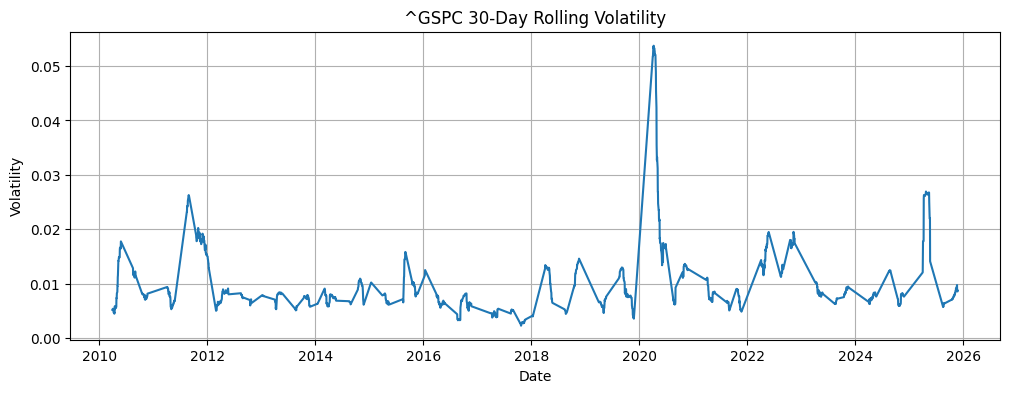

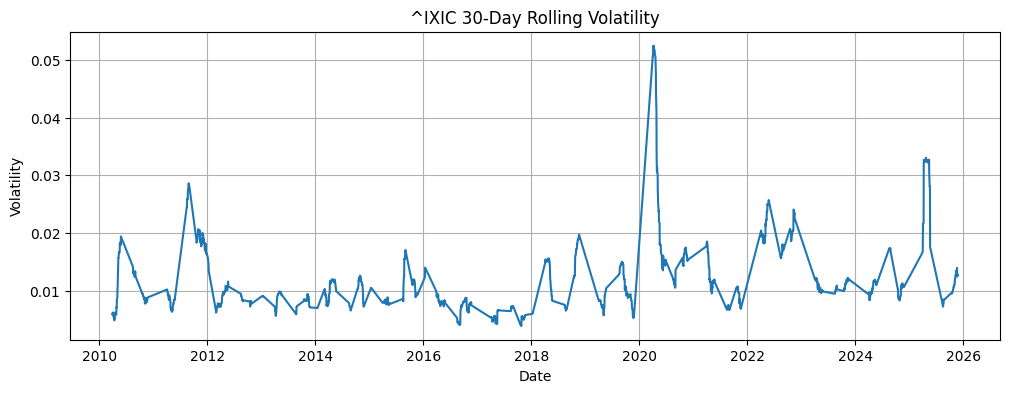

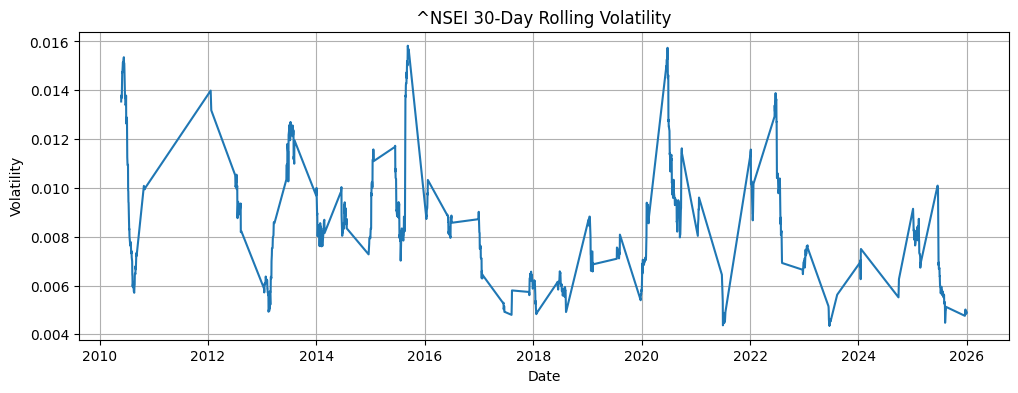

In [19]:
for ticker in features_clean["ticker"].unique():
    temp = features_clean[features_clean["ticker"] == ticker]

    plt.figure(figsize=(12, 4))
    plt.plot(temp["Date"], temp["volatility_30d"])
    plt.title(f"{ticker} 30-Day Rolling Volatility")
    plt.xlabel("Date")
    plt.ylabel("Volatility")
    plt.grid(True)
    plt.show()